In [9]:
# same as trainv12 (best results so far) but with 50 epochs and early stopping
import os
import sys

# Change to project root23
os.chdir('c:/Users/PC_ATIC_01/cats-dogs-classifier')

# ADD SRC TO PYTHON PATH 
sys.path.insert(0, 'src')

# Verify
print("Current directory:", os.getcwd())
print("Python path:", sys.path[:3])
print("Files in current directory:", os.listdir())

Current directory: c:\Users\PC_ATIC_01\cats-dogs-classifier
Python path: ['src', 'src', 'C:\\Users\\PC_ATIC_01\\AppData\\Local\\Python\\pythoncore-3.14-64\\python314.zip']
Files in current directory: ['%USERPROFILE%.kaggle', '%USERPROFILE%.kaggleaccess_token', '.git', '.gitattributes', '.gitignore', '.vscode', 'best_model.pth', 'data', 'dogs-vs-cats-redux-kernels-edition.zip', 'models', 'requirements.txt', 'sample_submission.csv', 'src', 'test.zip', 'train.zip', 'venv']


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
import os
from custom_model import CustomCNN

In [5]:
# ============ HYPERPARAMETERS ============
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.6
VAL_SPLIT = 0.2  # 20% for validation

In [6]:
# ============ MODEL ARCHITECTURE ============
NUM_CONV_LAYERS = 5
CONV_CHANNELS = [32, 64, 128, 256, 512]  # Output channels for each conv layer
KERNEL_SIZES = [3, 3, 3, 3, 3]  # Kernel size for each conv layer
POOL_TYPE = 'max'  # 'max' or 'avg'
NUM_HIDDEN_LAYERS = 2
HIDDEN_SIZES = [256, 128]  # Size of each hidden layer
ACTIVATION = 'relu'  # 'relu', 'elu', 'leaky_relu'

In [7]:
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch
from torch import nn, optim

# ============ SETUP ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("Loading data...")
full_dataset = ImageFolder('data/train_shuffled', transform=transform) 
print(f"Total images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

# Calculate class distribution
class_counts = [0, 0]
for img, label in full_dataset:
    class_counts[label] += 1
print(f"Class distribution: {full_dataset.classes[0]}={class_counts[0]}, {full_dataset.classes[1]}={class_counts[1]}")

# Split into train/validation
train_size = int((1 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {full_dataset.classes}")

# ===== CREATE BALANCED BATCHES =====
# First, count class occurrences in training set
class_counts = [0, 0]
for idx in train_dataset.indices:
    _, label = full_dataset[idx]
    class_counts[label] += 1

print(f"Training set: {class_counts[0]} cats, {class_counts[1]} dogs")

# Assign weights inversely proportional to class frequency
# Dogs (rare) get HIGH weight, Cats (common) get LOW weight
sample_weights = []
for idx in train_dataset.indices:
    _, label = full_dataset[idx]
    sample_weights.append(1.0 / class_counts[label])

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify balanced batches
print("\n✅ Verifying balanced batches:")
for images, labels in train_loader:
    cat_count = (labels == 0).sum().item()
    dog_count = (labels == 1).sum().item()
    print(f"Batch: {cat_count} cats, {dog_count} dogs")
    break

# Create model
print("\nCreating model...")
model = CustomCNN(
    num_conv_layers=NUM_CONV_LAYERS,
    conv_channels=CONV_CHANNELS,
    kernel_sizes=KERNEL_SIZES,
    pool_type=POOL_TYPE,
    dropout_rate=DROPOUT_RATE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    hidden_sizes=HIDDEN_SIZES,
    activation=ACTIVATION
)
model = model.to(device)

print(f"Model Architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss and optimizer (NO class weights needed!)
criterion = nn.CrossEntropyLoss()  # Standard loss, no weighting
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n✅ Setup complete with balanced batches!")

Using device: cpu
Loading data...
Total images: 23688
Classes: ['cat', 'dog']
Class distribution: cat=11338, dog=12350
Training samples: 18950
Validation samples: 4738
Classes: ['cat', 'dog']
Training set: 9094 cats, 9856 dogs

✅ Verifying balanced batches:
Batch: 15 cats, 17 dogs

Creating model...
Model Architecture:
CustomCNN(
  (activation): ReLU()
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1,

In [8]:
# ============ TRAINING WITH EARLY STOPPING ============
NUM_EPOCHS = 50  # CAN be higher now with early stopping!
best_val_acc = 0
patience = 5  # Stop if no improvement for 5 epochs
patience_counter = 0
best_epoch = 0

train_accs = []
val_accs = []
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # ===== TRAINING =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_acc = 100 * train_correct / train_total
    train_loss /= len(train_loader)
    
    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    val_loss /= len(val_loader)
    
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    # ===== EARLY STOPPING =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ Best model saved! (Val Acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n✅ Early stopping at epoch {epoch+1}")
            print(f"✅ Best validation was epoch {best_epoch+1} with {best_val_acc:.2f}% accuracy")
            # Load best model
            model.load_state_dict(torch.load('best_model.pth'))
            break

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)

Epoch [1/50]
  Train - Loss: 0.7681, Acc: 59.53%
  Val   - Loss: 0.6013, Acc: 68.07%
  ✓ Best model saved! (Val Acc: 68.07%)
Epoch [2/50]
  Train - Loss: 0.5963, Acc: 68.93%
  Val   - Loss: 0.5308, Acc: 74.31%
  ✓ Best model saved! (Val Acc: 74.31%)
Epoch [3/50]
  Train - Loss: 0.5117, Acc: 75.68%
  Val   - Loss: 0.4898, Acc: 77.86%
  ✓ Best model saved! (Val Acc: 77.86%)
Epoch [4/50]
  Train - Loss: 0.4397, Acc: 80.65%
  Val   - Loss: 0.3695, Acc: 85.90%
  ✓ Best model saved! (Val Acc: 85.90%)
Epoch [5/50]
  Train - Loss: 0.3538, Acc: 85.27%
  Val   - Loss: 0.3004, Acc: 87.34%
  ✓ Best model saved! (Val Acc: 87.34%)
Epoch [6/50]
  Train - Loss: 0.2902, Acc: 88.22%
  Val   - Loss: 0.2215, Acc: 90.76%
  ✓ Best model saved! (Val Acc: 90.76%)
Epoch [7/50]
  Train - Loss: 0.2524, Acc: 90.34%
  Val   - Loss: 0.2214, Acc: 90.88%
  ✓ Best model saved! (Val Acc: 90.88%)
Epoch [8/50]
  Train - Loss: 0.2111, Acc: 91.83%
  Val   - Loss: 0.2271, Acc: 91.05%
  ✓ Best model saved! (Val Acc: 91.05%)


Model saved to models/custom_cnn_model.pth
Results saved to models/training_resultsv15.png


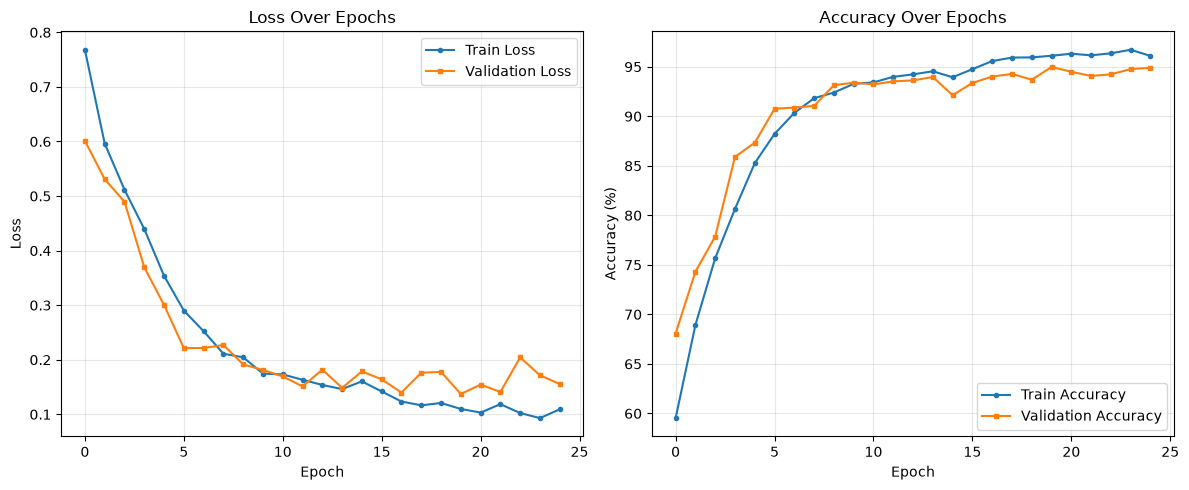

In [10]:
# ============ SAVE MODEL ============
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/custom_cnn_model.pth')
print("Model saved to models/custom_cnn_model.pth")

# ============ PLOT RESULTS ============
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o', markersize=3)
plt.plot(val_accs, label='Validation Accuracy', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/training_resultsv15.png', dpi=100)
print("Results saved to models/training_resultsv15.png")
plt.show()

In [11]:
# ============ DETECT OVERFITTING ============
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
gap = final_train_acc - final_val_acc

print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"Accuracy Gap: {gap:.2f}%")

if gap < 5:
    print("✓ Good! Minimal overfitting")
elif gap < 15:
    print("⚠️ Moderate overfitting - consider increasing dropout")
else:
    print("❌ Severe overfitting - try: more dropout, more regularization, or simpler model")


OVERFITTING ANALYSIS
Final Training Accuracy: 96.09%
Final Validation Accuracy: 94.89%
Accuracy Gap: 1.20%
✓ Good! Minimal overfitting


Confusion Matrix:
[[2128  116]
 [ 135 2359]]


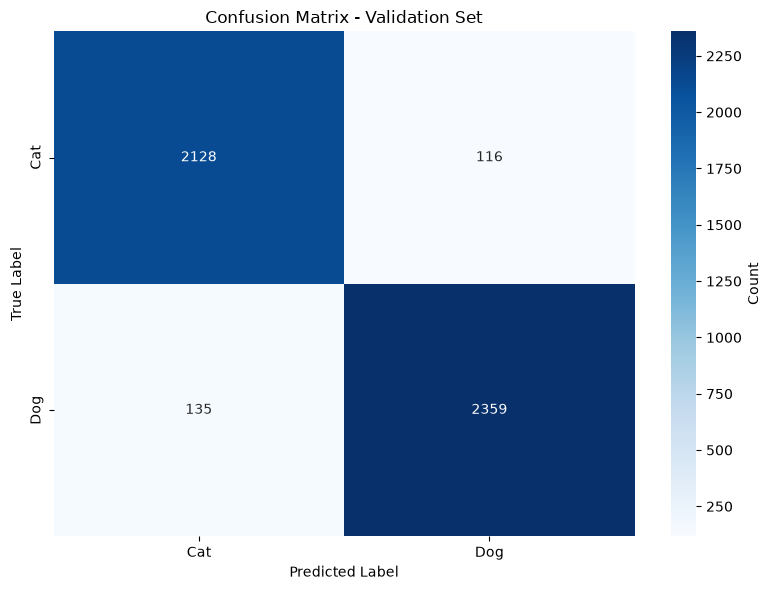


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Cat       0.94      0.95      0.94      2244
         Dog       0.95      0.95      0.95      2494

    accuracy                           0.95      4738
   macro avg       0.95      0.95      0.95      4738
weighted avg       0.95      0.95      0.95      4738



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ============ GENERATE CONFUSION MATRIX ============
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# ============ VISUALIZE CONFUSION MATRIX ============
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.savefig('models/confusion_matrixv15.png', dpi=100)
plt.show()

# ============ DETAILED METRICS ============
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, 
                          target_names=['Cat', 'Dog']))

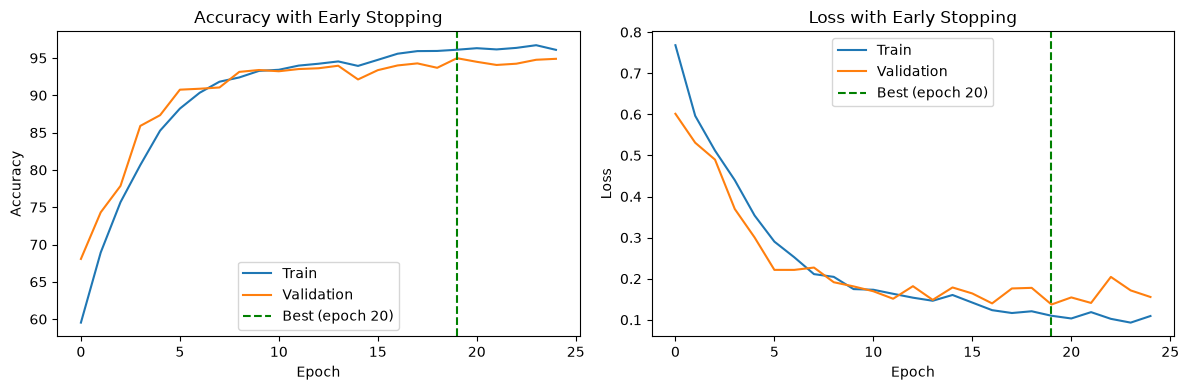

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best (epoch {best_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy with Early Stopping')

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best (epoch {best_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss with Early Stopping')

plt.tight_layout()
plt.show()